# Itô Integral

The Itô integral is the cornerstone of stochastic calculus. It allows us to integrate 
random functions with respect to Brownian motion — something ordinary calculus cannot do.

## The Problem

Consider:

$$I = \int_0^T W(t) \, dW(t)$$

If $W(t)$ were smooth, we'd use integration by parts:

$$\int_0^T W \, dW = \frac{1}{2}W(T)^2$$

But $W(t)$ is **not differentiable** — $dW/dt$ does not exist. The integral must be defined 
as a limit of sums.

## The Itô Sum

Partition $[0, T]$ into $N$ intervals with $\Delta t = T/N$:

$$I_N = \sum_{i=0}^{N-1} W(t_i) \cdot \Delta W_i$$

where $\Delta W_i = W(t_{i+1}) - W(t_i)$.

> **Critical choice**: We evaluate $W$ at the **left endpoint** $t_i$. This makes the Itô 
> integral a **martingale** — one of its most important properties.


## Why Riemann-Stieltjes Doesn't Work

For a smooth function $f$ and bounded variation $g$:

$$\int_0^T f \, dg = \lim_{N \to \infty} \sum_{i=0}^{N-1} f(\tau_i) [g(t_{i+1}) - g(t_i)]$$

The limit is **independent** of the choice of $\tau_i \in [t_i, t_{i+1}]$.

### For Brownian Motion, the Choice Matters!

| Evaluation Point | Result for $\int_0^T W \, dW$ |
|-----------------|------------------------------|
| **Left (Itô)** | $\frac{1}{2}(W(T)^2 - T)$ |
| **Right** | $\frac{1}{2}(W(T)^2 + T)$ |
| **Midpoint (Stratonovich)** | $\frac{1}{2}W(T)^2$ |

The difference comes from the **quadratic variation**:

$$\sum_{i=0}^{N-1} (\Delta W_i)^2 \to T \quad \text{as } N \to \infty$$

This non-zero quadratic variation is what makes stochastic calculus different from ordinary calculus.


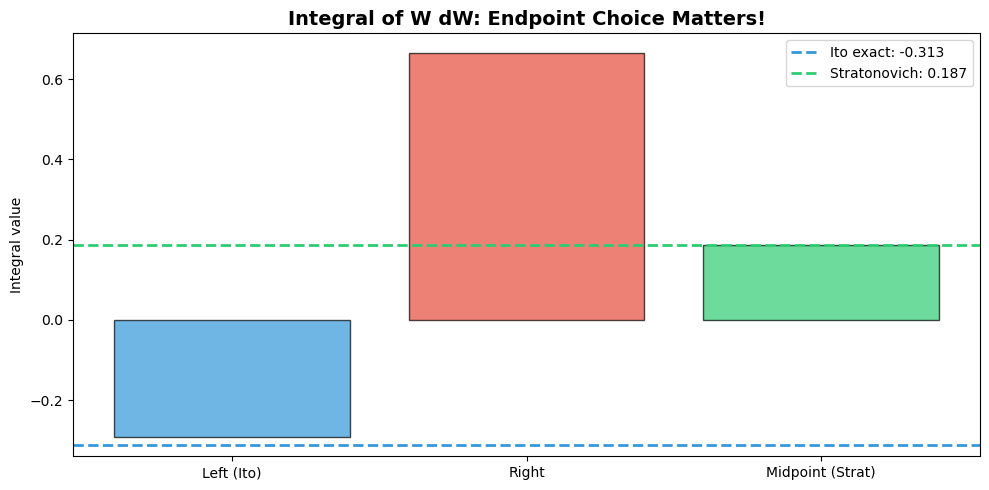

Ito (left):     -0.292275
Right endpoint: 0.666004
Midpoint:       0.186864
Exact Ito:      -0.313136
Exact Strat:    0.186864


In [38]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
T, N = 1.0, 1000
dt = T / N
t_grid = np.linspace(0, T, N+1)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

# Different evaluation points
ito_sum = np.sum(W[:-1] * dW)           # Left endpoint
right_sum = np.sum(W[1:] * dW)          # Right endpoint
mid_W = 0.5 * (W[:-1] + W[1:])
mid_sum = np.sum(mid_W * dW)            # Midpoint (Stratonovich)

exact_ito = 0.5 * (W[-1]**2 - T)
exact_strat = 0.5 * W[-1]**2

plt.figure(figsize=(10, 5))
plt.bar(['Left (Ito)', 'Right', 'Midpoint (Strat)'], 
        [ito_sum, right_sum, mid_sum], 
        color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='black')
plt.axhline(y=exact_ito, color='#3498db', linestyle='--', linewidth=2, 
            label='Ito exact: %.3f' % exact_ito)
plt.axhline(y=exact_strat, color='#2ecc71', linestyle='--', linewidth=2, 
            label='Stratonovich: %.3f' % exact_strat)
plt.title('Integral of W dW: Endpoint Choice Matters!', fontsize=14, fontweight='bold')
plt.ylabel('Integral value')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Ito (left):     {ito_sum:.6f}")
print(f"Right endpoint: {right_sum:.6f}")
print(f"Midpoint:       {mid_sum:.6f}")
print(f"Exact Ito:      {exact_ito:.6f}")
print(f"Exact Strat:    {exact_strat:.6f}")


## Quadratic Variation: The Signature of Randomness

For any partition of $[0, T]$:

$$[W, W](T) = \lim_{N \to \infty} \sum_{i=0}^{N-1} (W(t_{i+1}) - W(t_i))^2 = T$$

### Why This Matters

In ordinary calculus, for a smooth function $f$:

$$\sum_{i=0}^{N-1} (f(t_{i+1}) - f(t_i))^2 \to 0$$

For Brownian motion, the sum converges to $T$ (not zero!). This means:

$$(dW)^2 = dt \quad \text{(in the mean-square sense)}$$

This is the **fundamental identity** of stochastic calculus. It explains why:
- The chain rule needs a correction (Itô's lemma)
- $\int W \, dW \neq \frac{1}{2}W^2$
- Stochastic differential equations have extra drift terms
- 

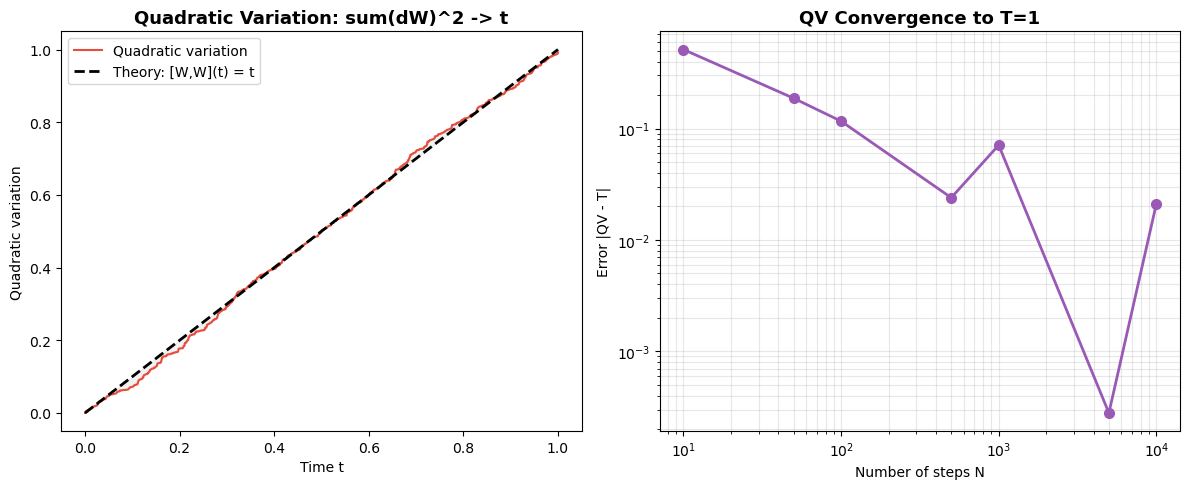

Final QV = 0.991991 (theory: 1.0)


In [39]:
np.random.seed(88)
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N+1)
dW = np.random.normal(0, np.sqrt(dt), N)

# Compute quadratic variation incrementally
qv = np.zeros(N + 1)
for i in range(1, N + 1):
    qv[i] = qv[i-1] + dW[i-1]**2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, qv, color='#e74c3c', linewidth=1.5, label='Quadratic variation')
plt.plot(t, t, 'k--', linewidth=2, label='Theory: [W,W](t) = t')
plt.fill_between(t, qv, t, alpha=0.1, color='gray')
plt.title('Quadratic Variation: sum(dW)^2 -> t', fontsize=13, fontweight='bold')
plt.xlabel('Time t')
plt.ylabel('Quadratic variation')
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
# Show convergence with N
N_values = [10, 50, 100, 500, 1000, 5000, 10000]
qv_errors = []
for N_test in N_values:
    dt_test = T / N_test
    dW_test = np.random.normal(0, np.sqrt(dt_test), N_test)
    qv_final = np.sum(dW_test**2)
    qv_errors.append(abs(qv_final - T))

plt.loglog(N_values, qv_errors, 'o-', color='#9b59b6', markersize=7, linewidth=2)
plt.title('QV Convergence to T=1', fontsize=13, fontweight='bold')
plt.xlabel('Number of steps N')
plt.ylabel('Error |QV - T|')
plt.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final QV = {qv[-1]:.6f} (theory: {T})")


## Itô Isometry

One of the most powerful tools for computing with Itô integrals:

$$\boxed{\mathbb{E}\left[\left(\int_0^T f(t) \, dW(t)\right)^2\right] = \mathbb{E}\left[\int_0^T f(t)^2 \, dt\right]}$$

### What It Tells Us

The "size" of the Itô integral is determined by the $L^2$ norm of the integrand.

### Example: $\int_0^T W(t) \, dW(t)$

By Itô isometry:

$$\mathbb{E}\left[\left(\int_0^T W \, dW\right)^2\right] = \mathbb{E}\left[\int_0^T W(t)^2 \, dt\right] = \int_0^T t \, dt = \frac{T^2}{2}$$

So the variance is $T^2/2$.

> **Key insight**: The Itô integral is a **martingale** with zero mean, and its variance 
> is given by the Itô isometry.


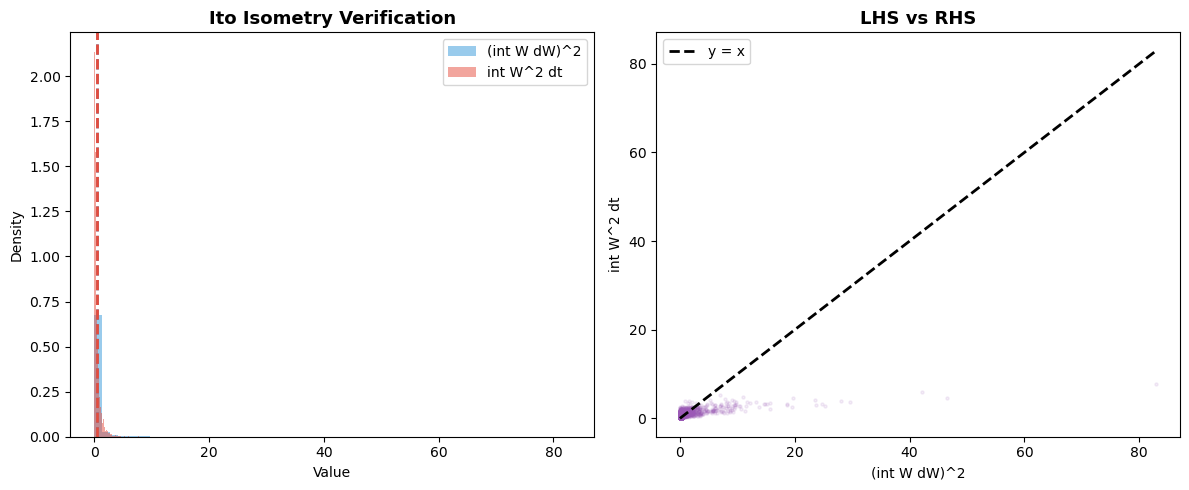

Mean LHS = 0.5083
Mean RHS = 0.5057
Theory = 0.5000


In [40]:
np.random.seed(99)
T = 1.0
n_sims = 5000

left_side = []
right_side = []

for _ in range(n_sims):
    N = 500
    dt = T / N
    dW = np.random.normal(0, np.sqrt(dt), N)
    W = np.concatenate([[0], np.cumsum(dW)])
    
    # Left side: (integral W dW)^2
    ito_int = np.sum(W[:-1] * dW)
    left_side.append(ito_int**2)
    
    # Right side: integral W^2 dt
    right_side.append(np.sum(W[:-1]**2 * dt))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(left_side, bins=60, density=True, alpha=0.5, color='#3498db', label='(int W dW)^2')
plt.hist(right_side, bins=60, density=True, alpha=0.5, color='#e74c3c', label='int W^2 dt')
plt.axvline(x=np.mean(left_side), color='#3498db', linestyle='--', linewidth=2)
plt.axvline(x=np.mean(right_side), color='#e74c3c', linestyle='--', linewidth=2)
plt.title('Ito Isometry Verification', fontsize=13, fontweight='bold')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
plt.scatter(left_side, right_side, alpha=0.1, s=5, color='#9b59b6')
plt.plot([0, max(max(left_side), max(right_side))], [0, max(max(left_side), max(right_side))], 
         'k--', linewidth=2, label='y = x')
plt.title('LHS vs RHS', fontsize=13, fontweight='bold')
plt.xlabel('(int W dW)^2')
plt.ylabel('int W^2 dt')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean LHS = {np.mean(left_side):.4f}")
print(f"Mean RHS = {np.mean(right_side):.4f}")
print(f"Theory = {T**2/2:.4f}")


## Common Itô Integrals and Their Exact Solutions

### 1. $\int_0^T dW(t) = W(T)$

Trivial — just the Brownian motion itself.

### 2. $\int_0^T W(t) \, dW(t) = \frac{1}{2}(W(T)^2 - T)$

**The Itô correction**: $-\frac{T}{2}$ appears because $(dW)^2 = dt$.

### 3. $\int_0^T t \, dW(t) = T \cdot W(T) - \int_0^T W(s) \, ds$

Integration by parts for Itô integrals.

### 4. $\int_0^T e^{W(t)} \, dW(t) = e^{W(T)} - 1 - \frac{1}{2}\int_0^T e^{W(s)} \, ds$

From Itô's lemma applied to $f(W) = e^W$.

> **Pattern**: Every Itô integral involving $W$ in the integrand gets a correction term 
> proportional to the quadratic variation.


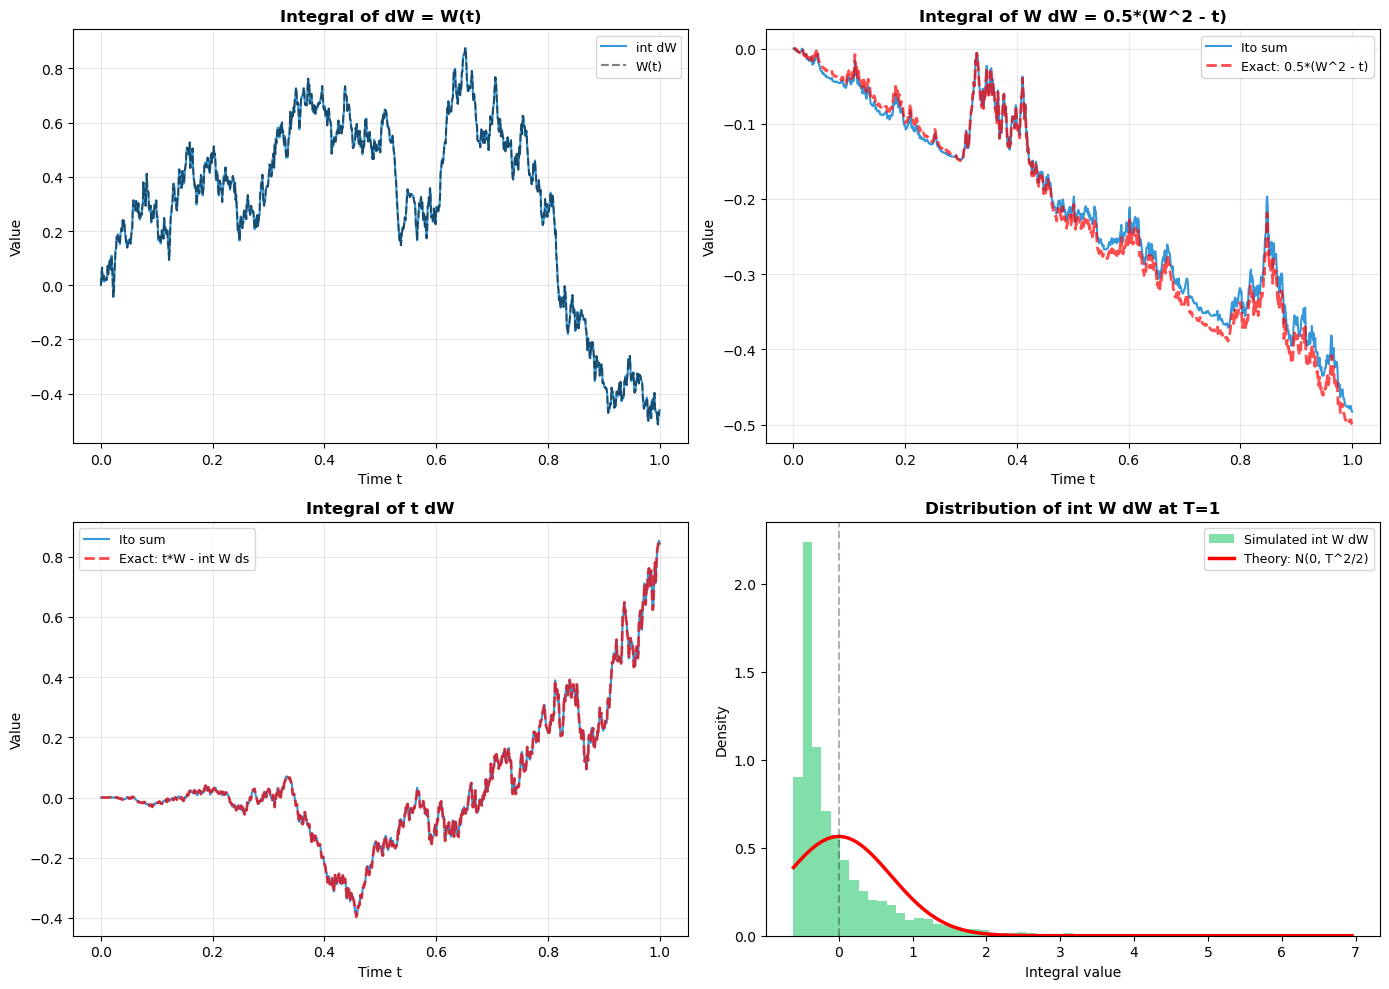

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Integral 1: int dW = W ---
ax = axes[0, 0]
np.random.seed(10)
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N+1)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

I_dW = np.concatenate([[0], np.cumsum(dW)])
ax.plot(t, I_dW, color='#3498db', linewidth=1.5, label='int dW')
ax.plot(t, W, 'k--', linewidth=1.5, alpha=0.5, label='W(t)')
ax.set_title('Integral of dW = W(t)', fontsize=12, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('Value')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Integral 2: int W dW = 0.5*(W^2 - t) ---
ax = axes[0, 1]
np.random.seed(20)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

I_WdW = np.concatenate([[0], np.cumsum(W[:-1] * dW)])
exact_WdW = 0.5 * (W**2 - t)
ax.plot(t, I_WdW, color='#3498db', linewidth=1.5, label='Ito sum')
ax.plot(t, exact_WdW, 'r--', linewidth=2, alpha=0.7, label='Exact: 0.5*(W^2 - t)')
ax.set_title('Integral of W dW = 0.5*(W^2 - t)', fontsize=12, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('Value')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Integral 3: int t dW ---
ax = axes[1, 0]
np.random.seed(30)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

I_tdW = np.concatenate([[0], np.cumsum(t[:-1] * dW)])
exact_tdW = t * W - np.concatenate([[0], np.cumsum(W[:-1] * dt)])
ax.plot(t, I_tdW, color='#3498db', linewidth=1.5, label='Ito sum')
ax.plot(t, exact_tdW, 'r--', linewidth=2, alpha=0.7, label='Exact: t*W - int W ds')
ax.set_title('Integral of t dW', fontsize=12, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('Value')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Distribution of int W dW at T=1 ---
ax = axes[1, 1]
np.random.seed(60)
n_sims = 5000
I_values = []

for _ in range(n_sims):
    N = 500
    dt = T / N
    dW = np.random.normal(0, np.sqrt(dt), N)
    W = np.concatenate([[0], np.cumsum(dW)])
    I = np.sum(W[:-1] * dW)
    I_values.append(I)

ax.hist(I_values, bins=60, density=True, alpha=0.6, color='#2ecc71', label='Simulated int W dW')
x_range = np.linspace(min(I_values), max(I_values), 300)
theory_pdf = stats.norm.pdf(x_range, 0, np.sqrt(T**2/2))
ax.plot(x_range, theory_pdf, 'r-', linewidth=2.5, label='Theory: N(0, T^2/2)')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Distribution of int W dW at T=1', fontsize=12, fontweight='bold')
ax.set_xlabel('Integral value')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Itô's Lemma: The Chain Rule of Stochastic Calculus

If $X(t)$ follows an Itô process:

$$dX = \mu(X,t) \, dt + \sigma(X,t) \, dW$$

And $Y(t) = f(X(t), t)$, then:

$$\boxed{df = \frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial x} dX + \frac{1}{2}\frac{\partial^2 f}{\partial x^2} (dX)^2}$$

### The Extra Term

Since $(dW)^2 = dt$:

$$(dX)^2 = \sigma^2 \, dt$$

So:

$$df = \left(\frac{\partial f}{\partial t} + \mu \frac{\partial f}{\partial x} + \frac{1}{2}\sigma^2 \frac{\partial^2 f}{\partial x^2}\right)dt + \sigma \frac{\partial f}{\partial x} dW$$

### Why the $1/2$?

In ordinary calculus, $d(x^2) = 2x \, dx$. In stochastic calculus:

$$d(W^2) = 2W \, dW + \underbrace{(dW)^2}_{= dt} = 2W \, dW + dt$$

So:

$$\int_0^T W \, dW = \frac{1}{2}(W(T)^2 - T)$$

The $-T/2$ is the **Itô correction**.


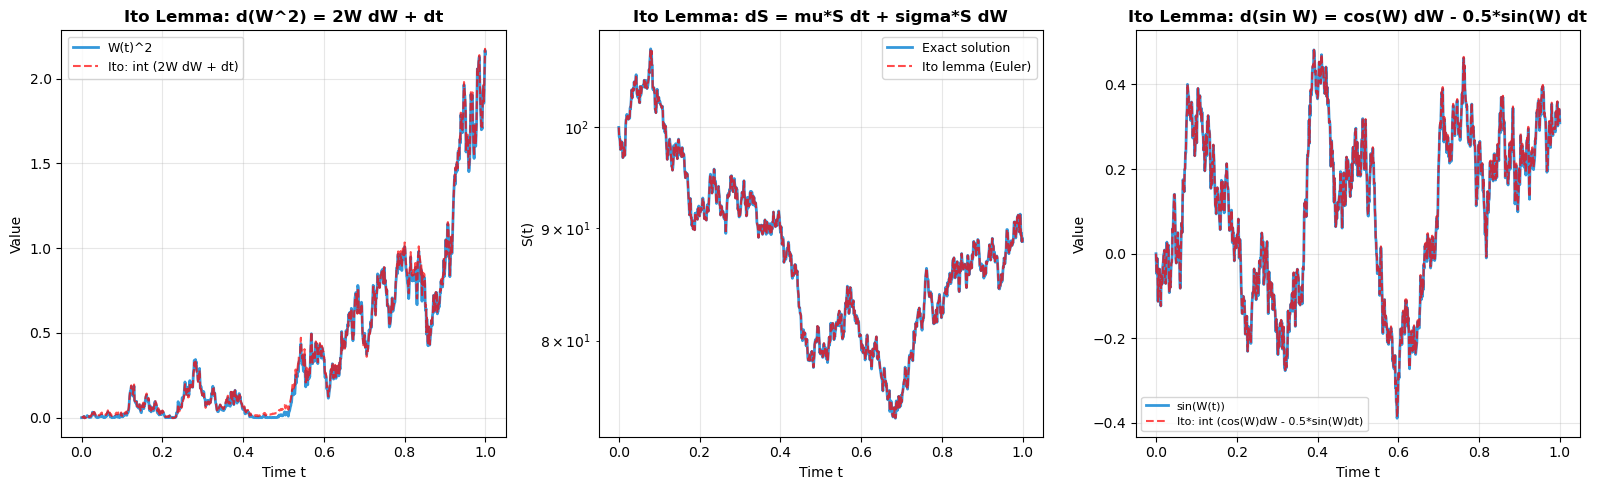

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Itô lemma for f(W) = W^2 ---
ax = axes[0]
np.random.seed(40)
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N+1)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

fW = W**2
ito_df = np.concatenate([[0], np.cumsum(2 * W[:-1] * dW + dt)])

ax.plot(t, fW, color='#3498db', linewidth=2, label='W(t)^2')
ax.plot(t, ito_df, 'r--', linewidth=1.5, alpha=0.7, label='Ito: int (2W dW + dt)')
ax.set_title('Ito Lemma: d(W^2) = 2W dW + dt', fontsize=12, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('Value')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Itô lemma for GBM ---
ax = axes[1]
np.random.seed(50)
S0, mu, sigma = 100, 0.05, 0.2
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

S_exact = S0 * np.exp((mu - 0.5*sigma**2)*t + sigma*W)
S_ito = np.zeros(N+1)
S_ito[0] = S0
for i in range(N):
    S_ito[i+1] = S_ito[i] + mu*S_ito[i]*dt + sigma*S_ito[i]*dW[i]

ax.plot(t, S_exact, color='#3498db', linewidth=2, label='Exact solution')
ax.plot(t, S_ito, 'r--', linewidth=1.5, alpha=0.7, label='Ito lemma (Euler)')
ax.set_title('Ito Lemma: dS = mu*S dt + sigma*S dW', fontsize=12, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('S(t)')
ax.legend(fontsize=9)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# --- Itô lemma for sin(W) ---
ax = axes[2]
np.random.seed(60)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

f = np.sin(W)
df_ito = np.concatenate([[0], np.cumsum(np.cos(W[:-1])*dW - 0.5*np.sin(W[:-1])*dt)])

ax.plot(t, f, color='#3498db', linewidth=2, label='sin(W(t))')
ax.plot(t, df_ito, 'r--', linewidth=1.5, alpha=0.7, label='Ito: int (cos(W)dW - 0.5*sin(W)dt)')
ax.set_title('Ito Lemma: d(sin W) = cos(W) dW - 0.5*sin(W) dt', fontsize=12, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('Value')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Itô vs Stratonovich: Two Interpretations

| | **Itô** | **Stratonovich** |
|---|---------|------------------|
| **Evaluation point** | Left endpoint $t_i$ | Midpoint $\frac{t_i + t_{i+1}}{2}$ |
| **Formula** | $\sum f(t_i) \Delta W_i$ | $\sum f(\frac{t_i+t_{i+1}}{2}) \Delta W_i$ |
| **Martingale?** | **Yes** | No |
| **Chain rule** | Needs correction | Ordinary chain rule applies |
| **Used in** | Finance, filtering | Physics, engineering |

### The Conversion Formula

For the same SDE:

$$\text{Itô: } dX = \mu \, dt + \sigma \, dW$$

$$\text{Stratonovich: } dX = \left(\mu - \frac{1}{2}\sigma \frac{\partial \sigma}{\partial x}\right) dt + \sigma \, dW$$

### Example: $\int_0^T W \, dW$

- **Itô**: $\frac{1}{2}(W(T)^2 - T)$
- **Stratonovich**: $\frac{1}{2}W(T)^2$

Difference = $T/2$ = half the quadratic variation.

> **When to use which?**
> - **Itô**: When you need martingales (finance, optimal control)
> - **Stratonovich**: When you want ordinary calculus rules (physics, rough paths)


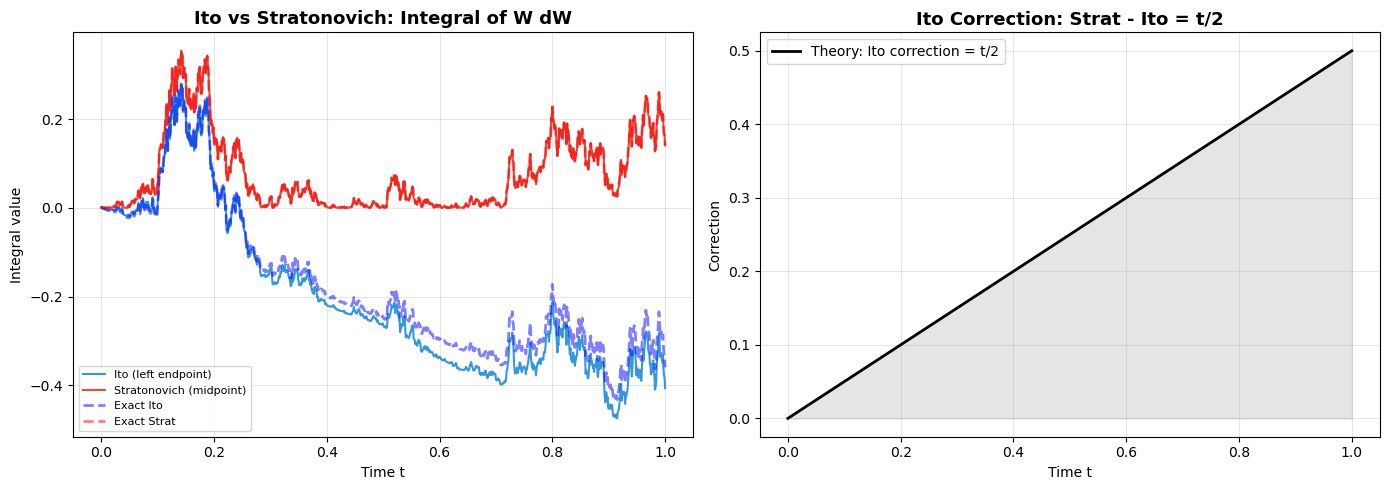

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Itô vs Stratonovich paths ---
ax = axes[0]
np.random.seed(100)
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N+1)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

ito_int = np.concatenate([[0], np.cumsum(W[:-1] * dW)])
mid_W = 0.5 * (W[:-1] + W[1:])
strat_int = np.concatenate([[0], np.cumsum(mid_W * dW)])
exact_ito = 0.5 * (W**2 - t)
exact_strat = 0.5 * W**2

ax.plot(t, ito_int, color='#3498db', linewidth=1.5, label='Ito (left endpoint)')
ax.plot(t, strat_int, color='#e74c3c', linewidth=1.5, label='Stratonovich (midpoint)')
ax.plot(t, exact_ito, 'b--', linewidth=2, alpha=0.5, label='Exact Ito')
ax.plot(t, exact_strat, 'r--', linewidth=2, alpha=0.5, label='Exact Strat')
ax.set_title('Ito vs Stratonovich: Integral of W dW', fontsize=13, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('Integral value')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Right: The correction term ---
ax = axes[1]
correction = 0.5 * t
ax.plot(t, correction, 'k-', linewidth=2, label='Theory: Ito correction = t/2')
ax.fill_between(t, 0, correction, alpha=0.2, color='gray')
ax.set_title('Ito Correction: Strat - Ito = t/2', fontsize=13, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('Correction')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## The Martingale Property

An Itô integral is always a **martingale**:

$$\mathbb{E}\left[\int_0^T f(t) \, dW(t) \,\middle|\, \mathcal{F}_s\right] = \int_0^s f(t) \, dW(t)$$

### What This Means

- The expected future value equals the current value
- **No drift** — the integral is "fair"
- $\mathbb{E}\left[\int_0^T f \, dW\right] = 0$

### Why Itô Chose the Left Endpoint

Evaluating at $t_i$ (before the increment $\Delta W_i$ is known) ensures the integrand 
is **independent** of the increment. This makes each term have zero mean:

$$\mathbb{E}[f(t_i) \cdot \Delta W_i] = f(t_i) \cdot \mathbb{E}[\Delta W_i] = 0$$

If we used the right endpoint, $f(t_{i+1})$ would **depend** on $\Delta W_i$, and the 
expectation would not be zero.

> **Finance intuition**: A martingale represents a "fair game." The Itô integral being 
> a martingale means you cannot systematically profit from it — the expected gain is zero.


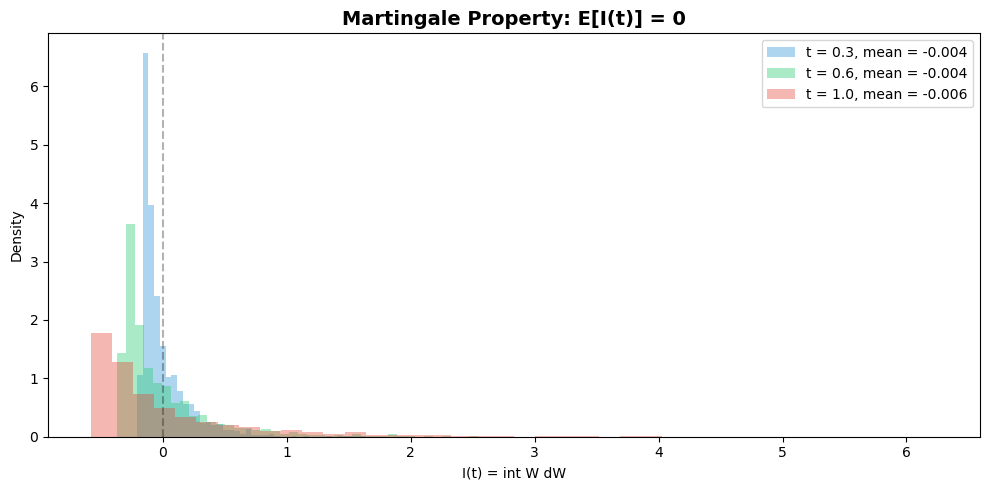

t = 0.3: mean = -0.0039, std = 0.2037
  Theory: mean = 0, std = 0.2121
t = 0.6: mean = -0.0036, std = 0.3948
  Theory: mean = 0, std = 0.4243
t = 1.0: mean = -0.0064, std = 0.6784
  Theory: mean = 0, std = 0.7071


In [44]:
np.random.seed(600)
T = 1.0
n_sims = 2000
N = 500

times = [0.3, 0.6, 1.0]
I_at_times = {t: [] for t in times}

for _ in range(n_sims):
    dt = T / N
    dW = np.random.normal(0, np.sqrt(dt), N)
    W = np.concatenate([[0], np.cumsum(dW)])
    I = np.concatenate([[0], np.cumsum(W[:-1] * dW)])
    
    for t_val in times:
        idx = int(t_val * N)
        I_at_times[t_val].append(I[idx])

plt.figure(figsize=(10, 5))
for t_val, color in zip(times, ['#3498db', '#2ecc71', '#e74c3c']):
    plt.hist(I_at_times[t_val], bins=40, density=True, alpha=0.4, color=color, 
             label='t = %.1f, mean = %.3f' % (t_val, np.mean(I_at_times[t_val])))

plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.title('Martingale Property: E[I(t)] = 0', fontsize=14, fontweight='bold')
plt.xlabel('I(t) = int W dW')
plt.ylabel('Density')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

for t_val in times:
    print(f"t = {t_val}: mean = {np.mean(I_at_times[t_val]):.4f}, std = {np.std(I_at_times[t_val]):.4f}")
    print(f"  Theory: mean = 0, std = {t_val/np.sqrt(2):.4f}")


## Complete Formula Reference

### Itô Integral Definition
$$I = \int_0^T f(t) \, dW(t) = \lim_{N \to \infty} \sum_{i=0}^{N-1} f(t_i) \Delta W_i$$

### Key Identities
| Integral | Result |
|----------|--------|
| $\int_0^T dW$ | $W(T)$ |
| $\int_0^T W \, dW$ | $\frac{1}{2}(W(T)^2 - T)$ |
| $\int_0^T t \, dW$ | $T W(T) - \int_0^T W(s) ds$ |
| $\int_0^T e^{W} dW$ | $e^{W(T)} - 1 - \frac{1}{2}\int_0^T e^{W} ds$ |

### Itô's Lemma
$$df = \frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial x} dX + \frac{1}{2}\frac{\partial^2 f}{\partial x^2}(dX)^2$$

### Itô Isometry
$$\mathbb{E}\left[\left(\int_0^T f \, dW\right)^2\right] = \mathbb{E}\left[\int_0^T f^2 \, dt\right]$$

### Itô vs Stratonovich
$$\int_0^T W \circ dW = \int_0^T W \, dW + \frac{T}{2} = \frac{1}{2}W(T)^2$$

### Martingale Property
$$\mathbb{E}\left[\int_0^T f \, dW \,\middle|\, \mathcal{F}_s\right] = \int_0^s f \, dW$$
